assumed nm units
χ² = 3.165


/Users/josh/Documents/PhD/NoLooseEnds_Lab/Wiggle_scattering/wiggle/plotting.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 1500x1200 with 2 Axes>,
 (<Axes: title={'center': 'Lysozyme SAXS Fit'}, ylabel='I(q)'>,
  <Axes: xlabel='q (A^-1)', ylabel='delta / sigma'>))

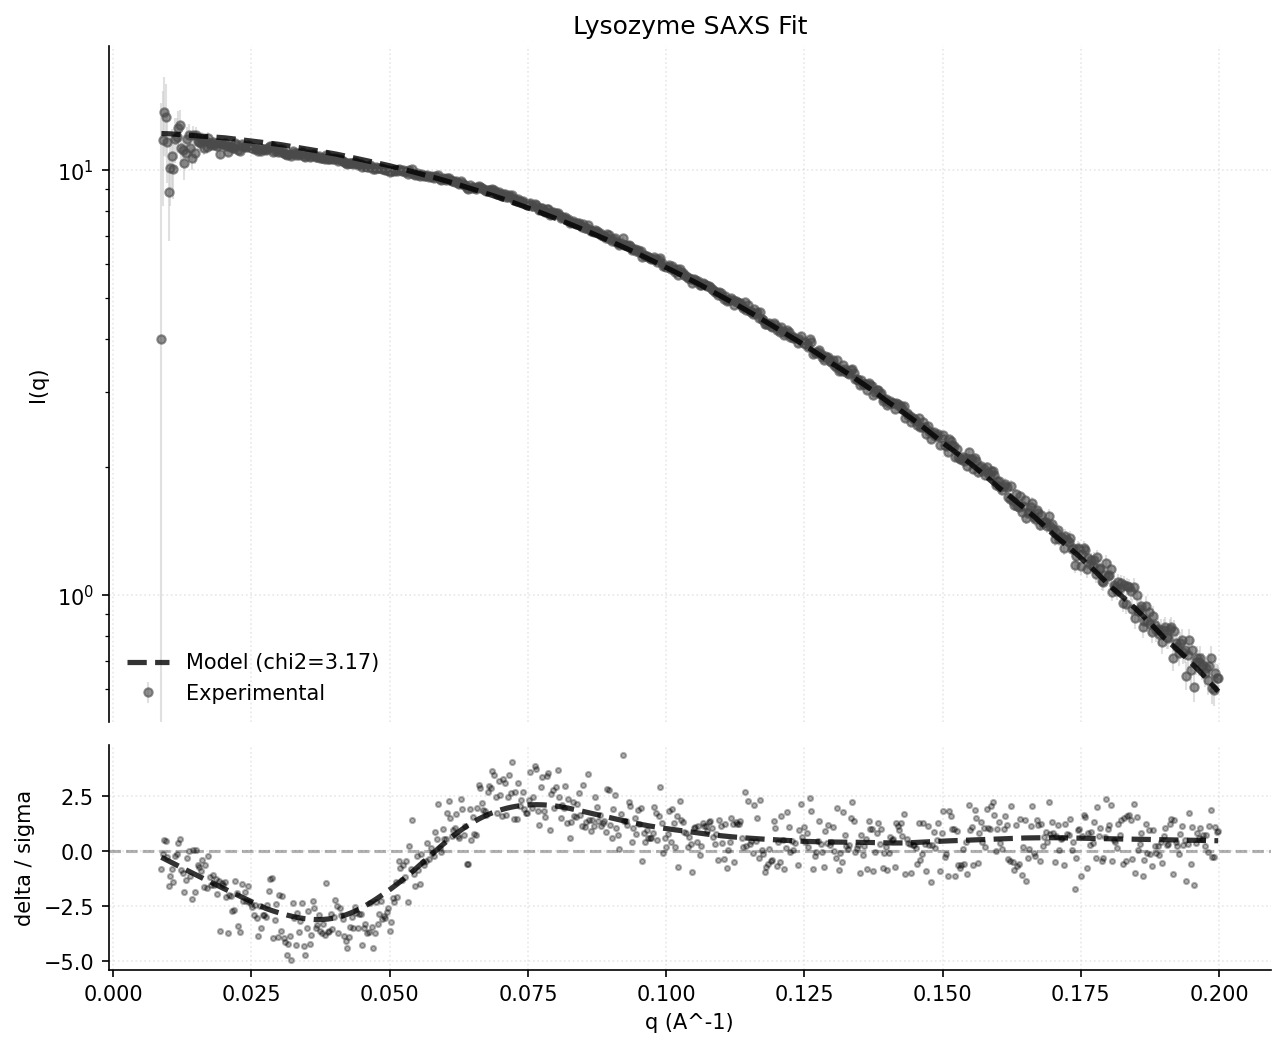

In [11]:
import wiggle

# for pdb file + saxs data file, compute model curve
result = wiggle.compute_fit("data/lysozyme.pdb", "data/lyso_SAXS.dat")

# -- result contains --
# result["q_model"]: [0, 0.01, 0.02 ... 0.2 ]
# result["I_model"]: calculated scattering intensity at each q_model point
# result["q_exp"]  : experimental q - cutoff at q=0.2 (A)
# result["I_exp"]  : experimental scattering intensity - cutoff at q=0.2 (A)
# result["I_err"]  : experimental error bars - cutoff at q=0.2 (A)

# -- Fit to data --
fit = wiggle.fit_model_to_data(
    result["q_model"], result["I_model"],
    result["q_exp"],   result["I_exp"], result["I_err"],
)
print(f"χ² = {fit['chi2']:.3f}")

# -- Plotting --
wiggle.plot_fit(
    result["q_exp"], result["I_exp"], result["I_err"],
    fit["q"], fit["I_scaled"],
    chi2=fit["chi2"],
    title="Lysozyme SAXS Fit",
    save_path=None,
)

## More control - if you have numpy arrays

In [2]:
from biopandas.pdb import PandasPdb

# example of CA coordinate numpy array and residue sequence

ppdb = PandasPdb().read_pdb('data/lysozyme.pdb')
atom_df = ppdb.df["ATOM"]
ca_df = atom_df[
    (atom_df["atom_name"] == "CA")
    & (atom_df["alt_loc"].isin(["", "A"]))
].copy()
ca_df.reset_index(drop=True, inplace=True)

ca_coords = ca_df[['x_coord', 'y_coord', 'z_coord']].values
sequence = ca_df['residue_name'].values

χ² = 3.165


/Users/josh/Documents/PhD/NoLooseEnds_Lab/Wiggle_scattering/wiggle/plotting.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 1500x1200 with 2 Axes>,
 (<Axes: title={'center': 'My protein'}, ylabel='I(q)'>,
  <Axes: xlabel='q (A^-1)', ylabel='delta / sigma'>))

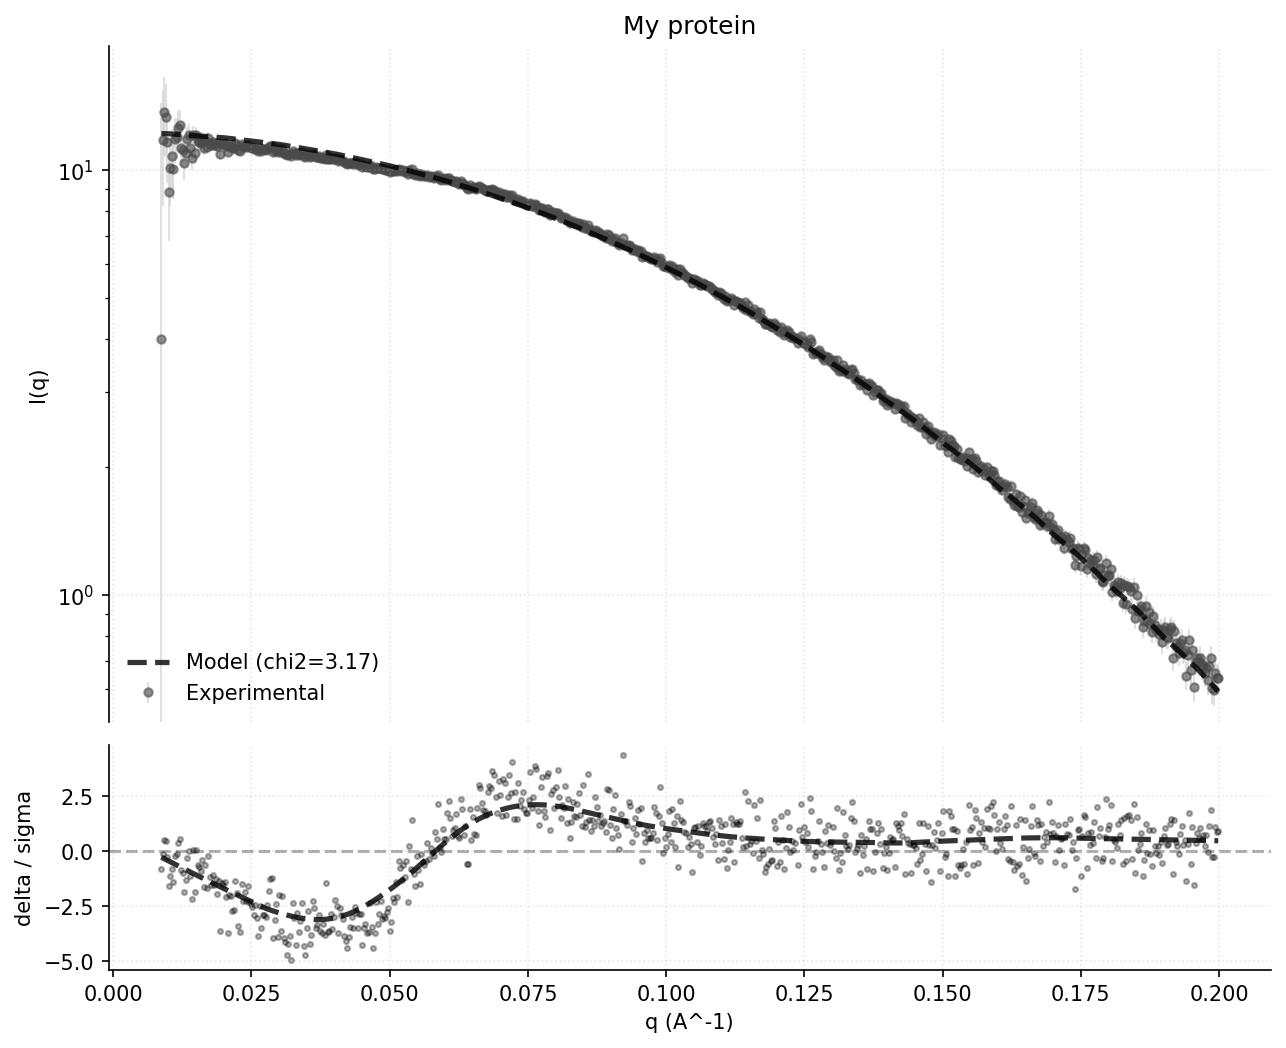

In [8]:
proc = wiggle.StructureProcessor()

# sequence one- or three- letter codes
structure = proc.process_from_arrays(ca_coords, sequence)

# Note if you have a multi-chain protein — pass chain_ids array matching to each protein length
# example here with two chains of 129 residues each, chain A and chain B
# chain_ids = np.array(["A"] * 129 + ["B"] * 129)
# structure = proc.process_from_arrays(ca_coords, sequence, chain_ids=chain_ids)

# then calculate scattering
q_wiggle, I_wiggle = wiggle.calculate_saxs(structure)

# -- Fit to data --
# need to have experimental data q_exp, I_exp, I_err cutoff at q=0.2 (A)
# change these to whatever you need!
q_exp = result["q_exp"]
I_exp = result["I_exp"]
I_err = result["I_err"]

fit = wiggle.fit_model_to_data(
    q_wiggle, I_wiggle,
    q_exp, I_exp, I_err
)
print(f"χ² = {fit['chi2']:.3f}")

wiggle.plot_fit(
    q_exp, I_exp, I_err,
    fit["q"], fit["I_scaled"],
    chi2=fit["chi2"],
    title="My protein",
    save_path=None,
)